In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pyreadr
import pandas as pd
import numpy as np

In [4]:
# Wallenbeck data
df_w = pd.read_csv('data/wallenbeck_event_table_v3.csv')
print(df_w.columns.tolist())
print(df_w.head(3).to_string())

['Country', 'Dimension', 'Year Adopted', 'Left-Censored (pre-1991)', 'Pre-Directive', 'EU Deadline', 'Source', 'Confidence', 'Notes', 'gold_plating_category', 'years_after_sweden', 'in_corpus_window', 'lag_reliability']
  Country                              Dimension  Year Adopted Left-Censored (pre-1991) Pre-Directive  EU Deadline Source Confidence                                                                                                                                     Notes    gold_plating_category  years_after_sweden  in_corpus_window       lag_reliability
0     AUT                      Gestation Housing          2012                       NO           YES         2013   Text       HIGH                     Slightly more space than EU minimum since 2012 (survey data). Pre-directive for the 2012 addition (EU deadline 2013).            PRE_DIRECTIVE                24.0              True              RELIABLE
1     AUT  gestation_housing (confinement limit)          2018      

In [5]:
print(df_w.columns.tolist())
print(df_w.shape)
print(df_w.to_string())

['Country', 'Dimension', 'Year Adopted', 'Left-Censored (pre-1991)', 'Pre-Directive', 'EU Deadline', 'Source', 'Confidence', 'Notes', 'gold_plating_category', 'years_after_sweden', 'in_corpus_window', 'lag_reliability']
(22, 13)
   Country                              Dimension  Year Adopted Left-Censored (pre-1991) Pre-Directive  EU Deadline     Source Confidence                                                                                                                                                                                                        Notes           gold_plating_category  years_after_sweden  in_corpus_window                      lag_reliability
0      AUT                      Gestation Housing          2012                       NO           YES         2013       Text       HIGH                                                                                        Slightly more space than EU minimum since 2012 (survey data). Pre-directive for the 2012 additio

DNK Tail Docking 2003 is classified as POST_DIRECTIVE_EXCEEDS_MINIMUM because the EU directive restricted routine docking in 1994 and Denmark's 2003 provision came after that. Denmark's provision is stricter than the EU's, not just a later adoption of the same standard. The lag reliability flag UNRELIABLE_LAG_POST_DIRECTIVE captures this.

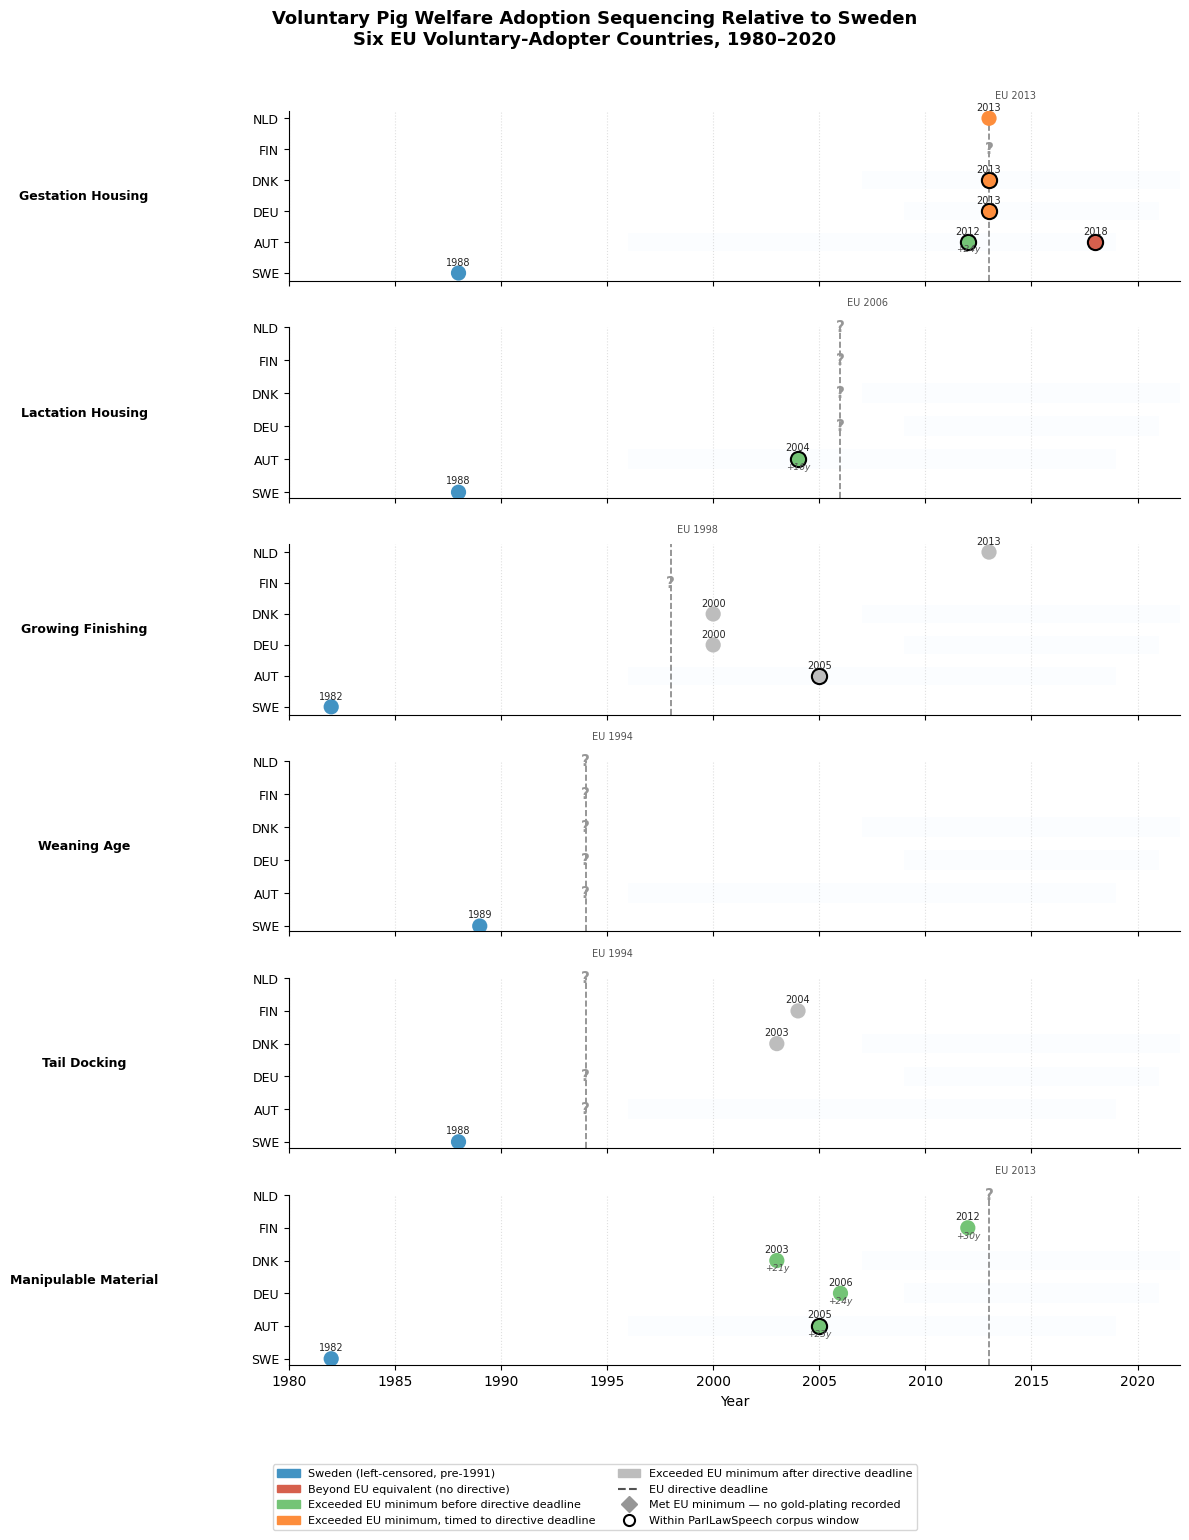

Saved adoption_sequencing_v2.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Plotting config ───────────────────────────────────────────────────────────

CATEGORY_COLOURS = {
    'LEFT_CENSORED':                '#4393C3',
    'BEYOND_NO_EU_EQUIVALENT':      '#D6604D',
    'PRE_DIRECTIVE':                '#74C476',
    'SAME_YEAR_EXCEEDS_MINIMUM':    '#FD8D3C',
    'POST_DIRECTIVE_EXCEEDS_MINIMUM':'#BDBDBD',
}

CATEGORY_LABELS = {
    'LEFT_CENSORED':                'Sweden (left-censored, pre-1991)',
    'BEYOND_NO_EU_EQUIVALENT':      'Beyond EU equivalent (no directive)',
    'PRE_DIRECTIVE':                'Exceeded EU minimum before directive deadline',
    'SAME_YEAR_EXCEEDS_MINIMUM':    'Exceeded EU minimum, timed to directive deadline',
    'POST_DIRECTIVE_EXCEEDS_MINIMUM':'Exceeded EU minimum after directive deadline',
}

EU_DEADLINES = {
    'Gestation Housing':    2013,
    'Lactation Housing':    2006,
    'Growing Finishing':    1998,
    'Weaning Age':          1994,
    'Tail Docking':         1994,
    'Manipulable Material': 2013,
}

COUNTRY_ORDER = ['SWE', 'AUT', 'DEU', 'DNK', 'FIN', 'NLD']

DIMENSION_ORDER = [
    'Gestation Housing',
    'Lactation Housing',
    'Growing Finishing',
    'Weaning Age',
    'Tail Docking',
    'Manipulable Material',
]

CORPUS_WINDOWS = {
    'AUT': (1996, 2019),
    'DEU': (2009, 2021),
    'DNK': (2007, 2022),
}

def normalise_dim(dim):
    dim = str(dim).strip()
    mapping = {
        'Gestation Housing':                    'Gestation Housing',
        'gestation_housing (confinement limit)':'Gestation Housing',
        'Lactation Housing':                    'Lactation Housing',
        'Growing Finishing':                    'Growing Finishing',
        'Weaning Age':                          'Weaning Age',
        'Tail Docking':                         'Tail Docking',
        'Manipulable Material':                 'Manipulable Material',
    }
    return mapping.get(dim, dim)

df_plot = df_w.copy()
df_plot['dim_display'] = df_plot['Dimension'].apply(normalise_dim)

# ── Build figure ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    nrows=len(DIMENSION_ORDER),
    ncols=1,
    figsize=(12, 14),
    sharex=True
)

fig.suptitle(
    'Voluntary Pig Welfare Adoption Sequencing Relative to Sweden\n'
    'Six EU Voluntary-Adopter Countries, 1980–2020',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, dim in zip(axes, DIMENSION_ORDER):

    subset = df_plot[df_plot['dim_display'] == dim].copy()

    # Draw EU directive deadline
    if dim in EU_DEADLINES:
        deadline = EU_DEADLINES[dim]
        ax.axvline(
            x=deadline, color='#525252', linewidth=1.2,
            linestyle='--', alpha=0.7
        )
        ax.text(
            deadline + 0.3, len(COUNTRY_ORDER) - 0.1,
            f'EU {deadline}', fontsize=7, color='#525252', va='top'
        )

    # Plot each country
    for y_pos, country in enumerate(COUNTRY_ORDER):
        country_rows = subset[subset['Country'] == country]

        # Shade corpus window
        if country in CORPUS_WINDOWS:
            start, end = CORPUS_WINDOWS[country]
            ax.barh(
                y_pos, end - start, left=start, height=0.6,
                color='#F7FBFF', alpha=0.4, zorder=0
            )

        if country_rows.empty:
            # Met EU minimum but no gold-plating recorded
            deadline = EU_DEADLINES.get(dim, 2013)
            ax.text(
                deadline, y_pos, '?',
                fontsize=11, ha='center', va='center',
                color='#969696', fontweight='bold'
            )
            continue

        for _, row in country_rows.iterrows():
            colour = CATEGORY_COLOURS.get(
                row['gold_plating_category'], '#BDBDBD'
            )
            edgecolour = 'black' if row['in_corpus_window'] else 'none'

            ax.scatter(
                row['Year Adopted'], y_pos,
                color=colour, s=120,
                edgecolors=edgecolour, linewidths=1.5,
                zorder=3
            )

            # Annotate year
            ax.text(
                row['Year Adopted'], y_pos + 0.25,
                str(int(row['Year Adopted'])),
                fontsize=7, ha='center', color='#252525'
            )

            # Annotate reliable lags
            if (row['lag_reliability'] == 'RELIABLE' and
                row['Country'] != 'SWE' and
                not np.isnan(row['years_after_sweden'])):
                ax.text(
                    row['Year Adopted'], y_pos - 0.32,
                    f"+{int(row['years_after_sweden'])}y",
                    fontsize=6.5, ha='center',
                    color='#525252', style='italic'
                )

    # Axis formatting
    ax.set_yticks(range(len(COUNTRY_ORDER)))
    ax.set_yticklabels(COUNTRY_ORDER, fontsize=9)
    ax.set_ylabel(dim, fontsize=9, fontweight='bold', rotation=0,
                  labelpad=120, va='center')
    ax.set_xlim(1980, 2022)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year', fontsize=10)

# ── Legend ────────────────────────────────────────────────────────────────────

legend_elements = [
    mpatches.Patch(color=CATEGORY_COLOURS[cat], label=CATEGORY_LABELS[cat])
    for cat in CATEGORY_COLOURS
]
legend_elements.append(
    plt.Line2D([0], [0], linestyle='--', color='#525252',
               label='EU directive deadline')
)
legend_elements.append(
    plt.Line2D([0], [0], marker='D', color='w',
               markerfacecolor='#969696', markersize=8,
               markeredgecolor='#969696',
               label='Met EU minimum — no gold-plating recorded')
)
legend_elements.append(
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='white', markersize=8,
               markeredgecolor='black', markeredgewidth=1.5,
               label='Within ParlLawSpeech corpus window')
)

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    fontsize=8,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.savefig(
    'adoption_sequencing_v2.png',
    dpi=180, bbox_inches='tight'
)
plt.show()
print("Saved adoption_sequencing_v2.png")